# Random vs UCB Stochastic Approximation

Compare `StochasticApproximation` (pure random search) against `StochasticApproximationUCBDynamic` (UCB over an adaptive binary partition) on a list of trained `ReLUNet`s.

Pipeline per architecture:
1. Train the network on a synthetic regression target.
2. Estimate ground-truth Lipschitz constant with random SA at a large iteration budget.
3. Run both methods across `N_SEEDS` repeats with a smaller budget.
4. Plot mean ± std convergence bands vs iterations and vs wall-clock time.

In [7]:
import sys, time
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from relu_nets import ReLUNet
from hyperbox import Hyperbox
from other_methods import StochasticApproximation, StochasticApproximationUCBDynamic

## Config — edit this cell

In [8]:
ARCHITECTURES = [
    [2, 32, 32, 1],
    [3, 32, 32, 32, 1],
    [4, 32, 32, 32, 1],
    [4, 64, 64, 64, 64, 1],
    [8, 32, 32, 32, 1],
    [8, 64, 64, 64, 64, 1],
]

DOMAIN_RADIUS = 1.0
PRIMAL_NORM   = 'linf'

TRAIN_SAMPLES = 4096
TRAIN_EPOCHS  = 1500
TRAIN_LR      = 1e-3
TRAIN_SEED    = 0

GT_ITERS      = 1000_000

COMPARE_ITERS = 500_000
N_SEEDS       = 5
SEEDS         = list(range(N_SEEDS))

UCB_C         = 15
UCB_PARTITION = 2

TOL_FRAC      = 0.01   # "reached the bound" = best-so-far >= (1 - TOL_FRAC) * target,
                       # where target = max(gt_value, max across all seeds/methods)

## Helpers

Two thin subclasses mirror the original solver loops (`other_methods/stochastic_approximation.py:30-60`, `other_methods/stochastic_approximation_ucb_dynamic.py:308-345`) and add per-iteration history (best-so-far value + wall time).

In [9]:
def train_network(arch, n_samples, epochs, lr, domain_radius, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    net = ReLUNet(arch)
    d = arch[0]
    X = (torch.rand(n_samples, d) * 2 - 1) * domain_radius
    y = torch.sin(X.norm(dim=1, keepdim=True)) + 0.1 * X[:, :1]
    opt  = torch.optim.Adam(net.parameters(), lr=lr)
    loss = torch.nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss(net(X), y).backward()
        opt.step()
    return net


class RandomSAHist(StochasticApproximation):
    def compute(self, max_iter=10000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        random_pts = self.domain.random_point(num_points=max_iter, requires_grad=False)
        random_pts = random_pts.to(self.DEVICE).detach().requires_grad_(True)
        t0 = time.perf_counter()
        for it in range(max_iter):
            fx = self.f(random_pts[it])
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value.cpu().detach().numpy().squeeze()


class UCBSAHist(StochasticApproximationUCBDynamic):
    def compute(self, max_iter=1000, **_):
        self.history_value = np.empty(max_iter, dtype=np.float64)
        self.history_time  = np.empty(max_iter, dtype=np.float64)
        self.iteration_count = 0
        next_partition = self.partition_step
        step_mul = self.partition_step
        self.space.max_iter = max_iter
        t0 = time.perf_counter()
        for it in range(max_iter):
            if it == next_partition:
                self.space.increment()
                next_partition = next_partition * step_mul
            reg = self.space.choose_region()
            x = reg.get_random_points(1)
            fx = self.f(x)
            fx_scalar = float(fx.detach().cpu().item())
            x_np = x.detach().cpu().numpy().reshape(-1)[:self.space.dimension]
            self.space.add_evaluation(x_np, fx_scalar)
            if self.value < fx:
                self.value = torch.maximum(self.value, fx)
                self.answer_coords = x.detach().cpu().numpy()
            self.iteration_count += 1
            self.history_value[it] = float(self.value)
            self.history_time[it]  = time.perf_counter() - t0
        self.compute_time = float(self.history_time[-1])
        return self.value


def aggregate_iter(histories):
    arr = np.stack(histories, axis=0)
    return arr.mean(axis=0), arr.std(axis=0)


def aggregate_time(value_hists, time_hists, n_grid=200):
    t_max = min(t[-1] for t in time_hists)
    grid = np.linspace(0.0, t_max, n_grid)
    interp = np.stack([np.interp(grid, t, v) for t, v in zip(time_hists, value_hists)], axis=0)
    return grid, interp.mean(axis=0), interp.std(axis=0)

## Run the experiment

In [10]:
results = {}
for arch in ARCHITECTURES:
    print(f'=== {arch} ===')
    net = train_network(arch, TRAIN_SAMPLES, TRAIN_EPOCHS, TRAIN_LR, DOMAIN_RADIUS, seed=TRAIN_SEED)
    domain   = Hyperbox.build_custom_hypercube(arch[0], 0, DOMAIN_RADIUS)
    c_vector = torch.ones(arch[-1])

    print(f'  ground truth ({GT_ITERS} iters)...')
    gt_solver = StochasticApproximation(net, c_vector, domain, primal_norm=PRIMAL_NORM)
    gt_value  = float(gt_solver.compute(max_iter=GT_ITERS))
    print(f'  ground truth = {gt_value:.6f}')

    rand_v_hist, rand_t_hist = [], []
    ucb_v_hist,  ucb_t_hist  = [], []
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        rand = RandomSAHist(net, c_vector, domain, primal_norm=PRIMAL_NORM)
        rand.compute(max_iter=COMPARE_ITERS)
        rand_v_hist.append(rand.history_value)
        rand_t_hist.append(rand.history_time)

        torch.manual_seed(seed); np.random.seed(seed)
        ucb = UCBSAHist(net, c_vector, domain, c=UCB_C,
                        partition_step=UCB_PARTITION, primal_norm=PRIMAL_NORM)
        ucb.compute(max_iter=COMPARE_ITERS)
        ucb_v_hist.append(ucb.history_value)
        ucb_t_hist.append(ucb.history_time)

        print(f'  seed {seed}: rand={rand.history_value[-1]:.4f} ({rand.compute_time:.2f}s)  '
              f'ucb={ucb.history_value[-1]:.4f} ({ucb.compute_time:.2f}s)')

    rand_iter_mean, rand_iter_std = aggregate_iter(rand_v_hist)
    ucb_iter_mean,  ucb_iter_std  = aggregate_iter(ucb_v_hist)
    rand_tg, rand_tm, rand_ts = aggregate_time(rand_v_hist, rand_t_hist)
    ucb_tg,  ucb_tm,  ucb_ts  = aggregate_time(ucb_v_hist,  ucb_t_hist)

    results[tuple(arch)] = dict(
        gt=gt_value,
        rand=dict(iter_mean=rand_iter_mean, iter_std=rand_iter_std,
                  time_grid=rand_tg, time_mean=rand_tm, time_std=rand_ts,
                  v_hist=rand_v_hist, t_hist=rand_t_hist),
        ucb=dict(iter_mean=ucb_iter_mean, iter_std=ucb_iter_std,
                 time_grid=ucb_tg, time_mean=ucb_tm, time_std=ucb_ts,
                 v_hist=ucb_v_hist, t_hist=ucb_t_hist),
    )

=== [2, 32, 32, 1] ===
  ground truth (1000000 iters)...
  ground truth = 1.431488
  seed 0: rand=1.4315 (31.32s)  ucb=1.4315 (52.70s)
  seed 1: rand=1.4315 (31.41s)  ucb=1.4315 (52.00s)
  seed 2: rand=1.4315 (31.36s)  ucb=1.4315 (51.72s)
  seed 3: rand=1.4315 (31.37s)  ucb=1.4315 (51.22s)
  seed 4: rand=1.4315 (31.23s)  ucb=1.4315 (52.08s)
=== [3, 32, 32, 32, 1] ===
  ground truth (1000000 iters)...
  ground truth = 1.933636
  seed 0: rand=1.9336 (36.97s)  ucb=1.9370 (60.13s)
  seed 1: rand=1.9336 (36.77s)  ucb=1.9370 (60.35s)
  seed 2: rand=1.9370 (36.98s)  ucb=1.9370 (58.92s)
  seed 3: rand=1.9336 (37.18s)  ucb=1.9370 (63.53s)
  seed 4: rand=1.9336 (37.05s)  ucb=1.9370 (60.76s)
=== [4, 32, 32, 32, 1] ===
  ground truth (1000000 iters)...
  ground truth = 2.140975
  seed 0: rand=2.1582 (37.01s)  ucb=2.1879 (62.60s)
  seed 1: rand=2.1317 (36.96s)  ucb=2.1879 (61.59s)
  seed 2: rand=2.1582 (37.14s)  ucb=2.1879 (61.20s)
  seed 3: rand=2.1414 (37.50s)  ucb=2.1879 (61.00s)
  seed 4: rand=

## Convergence — mean ± std vs iterations and vs time

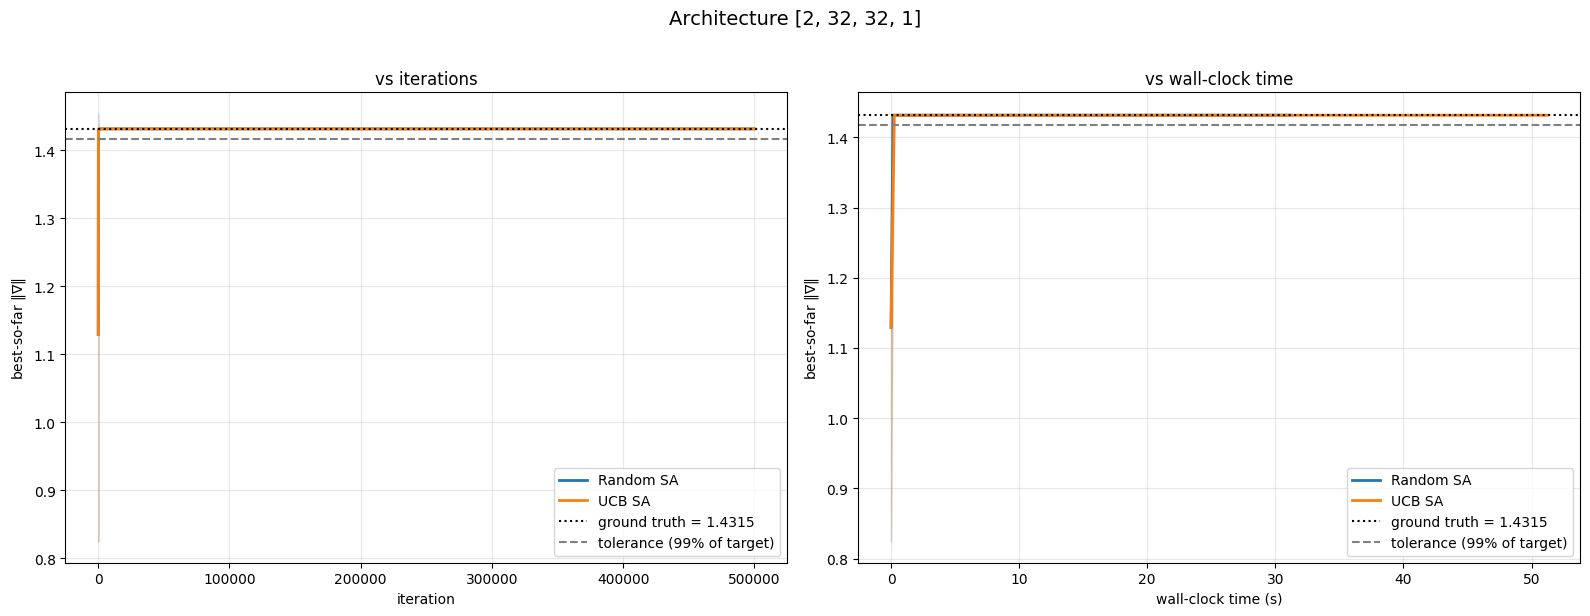

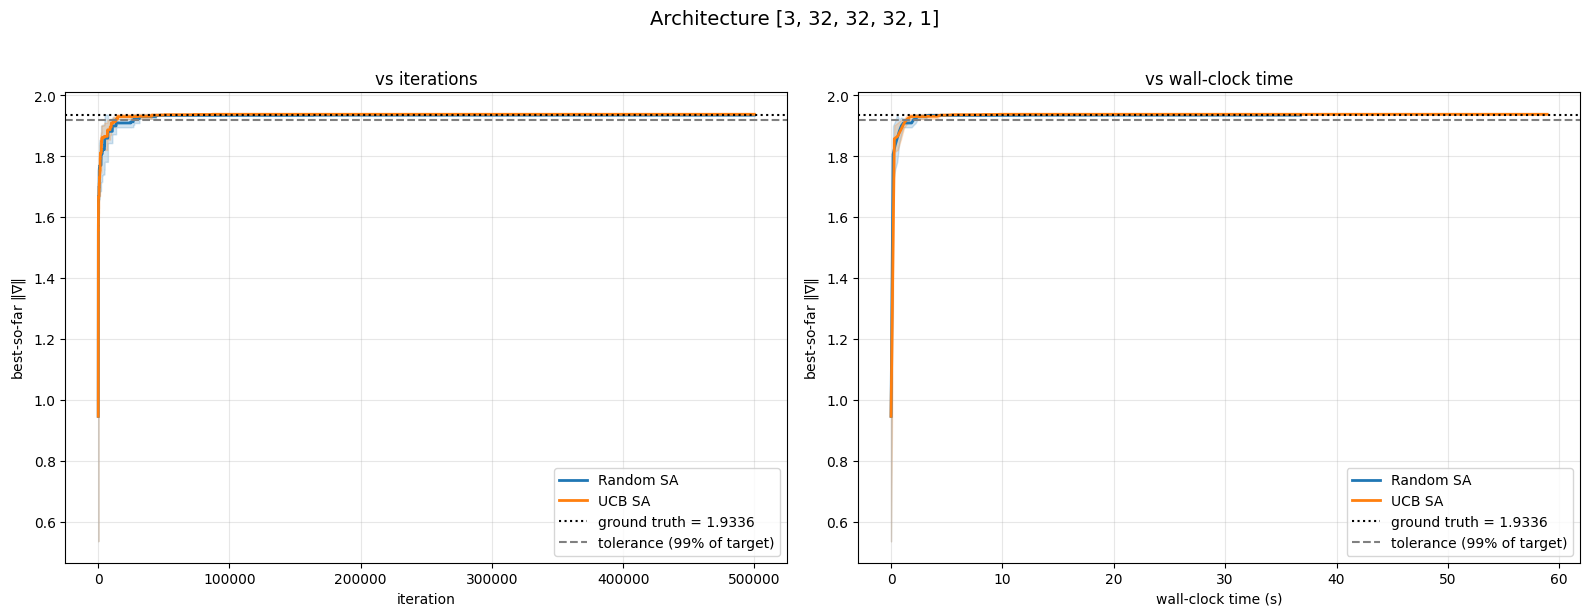

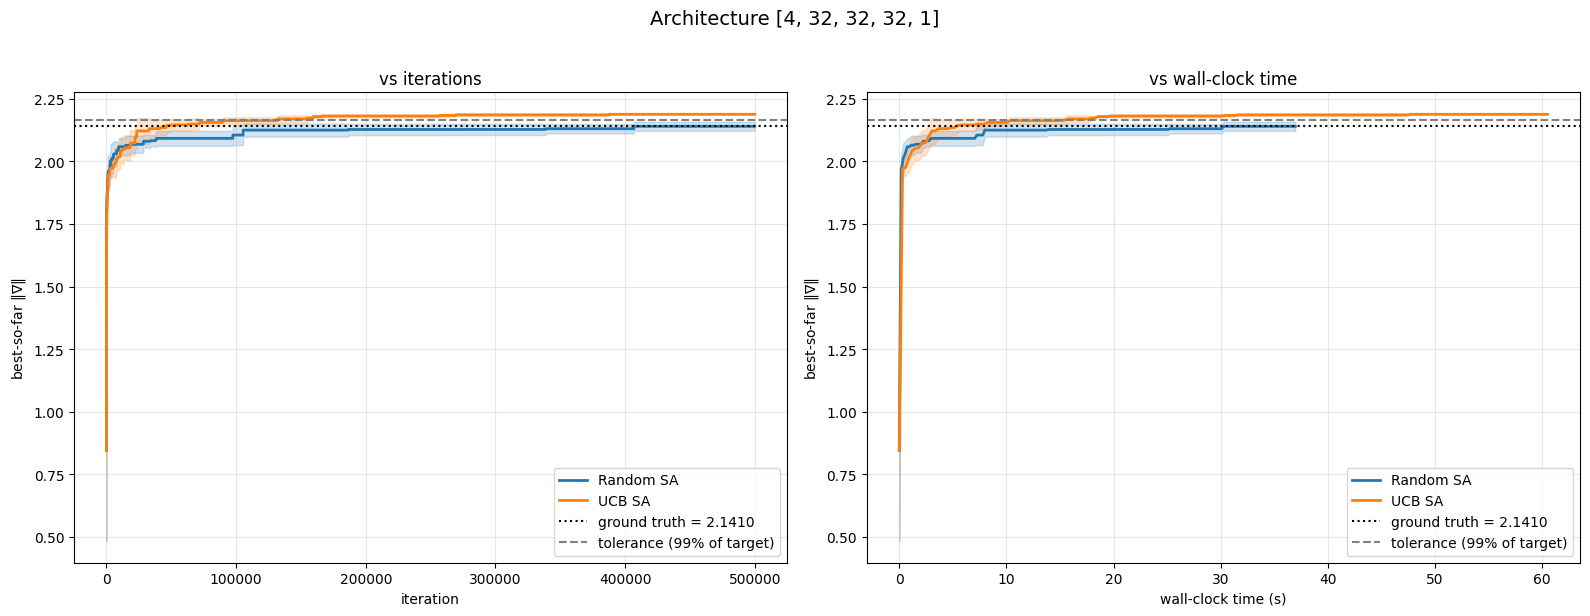

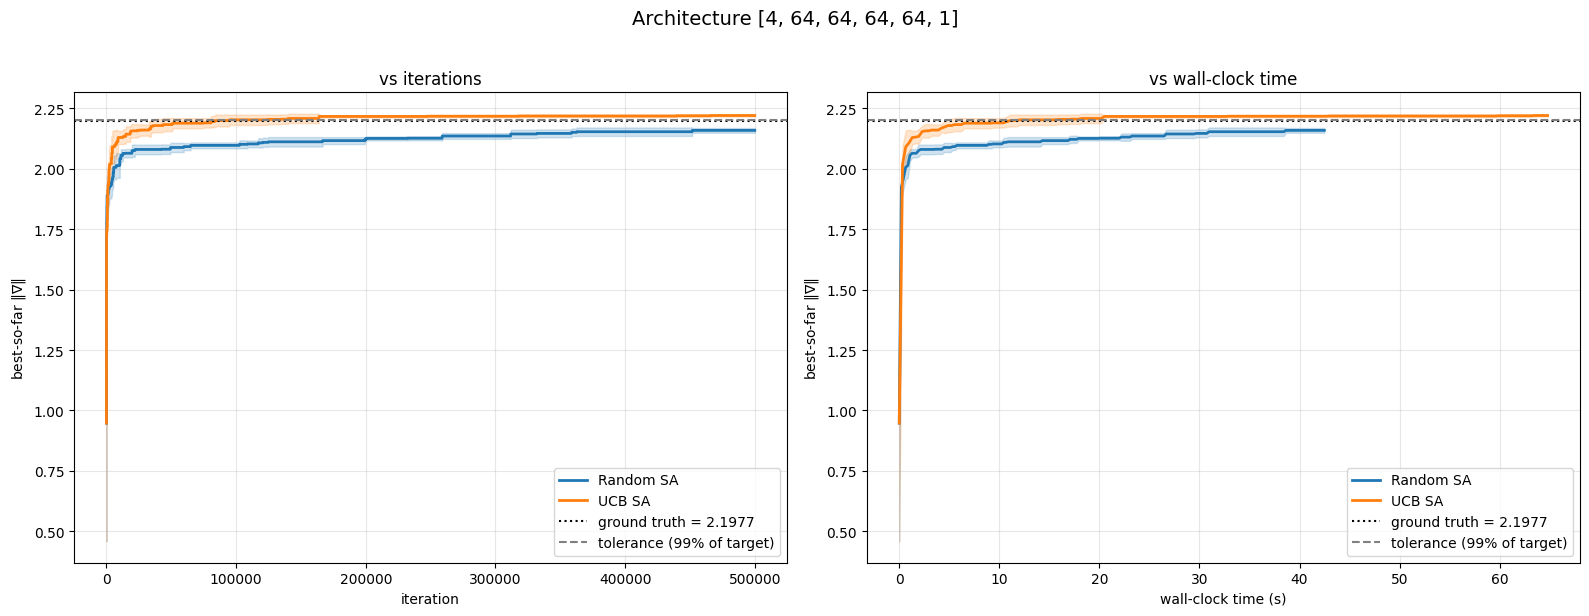

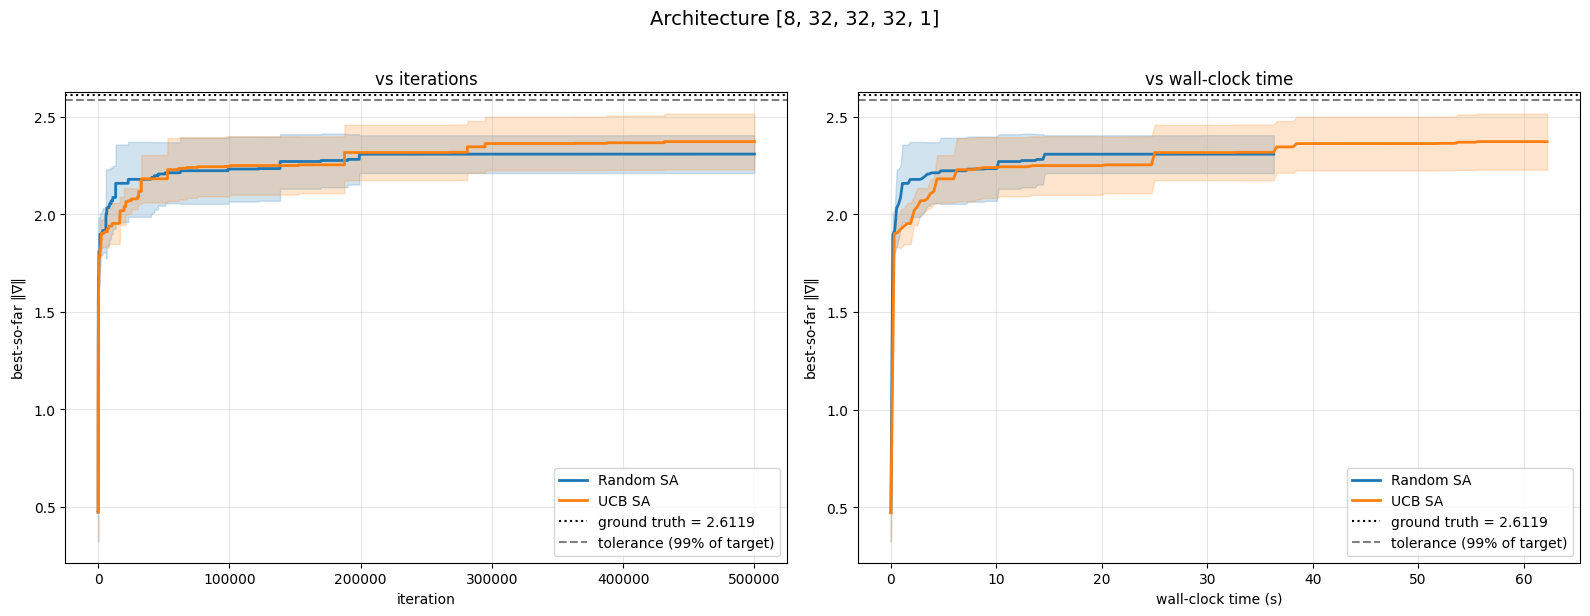

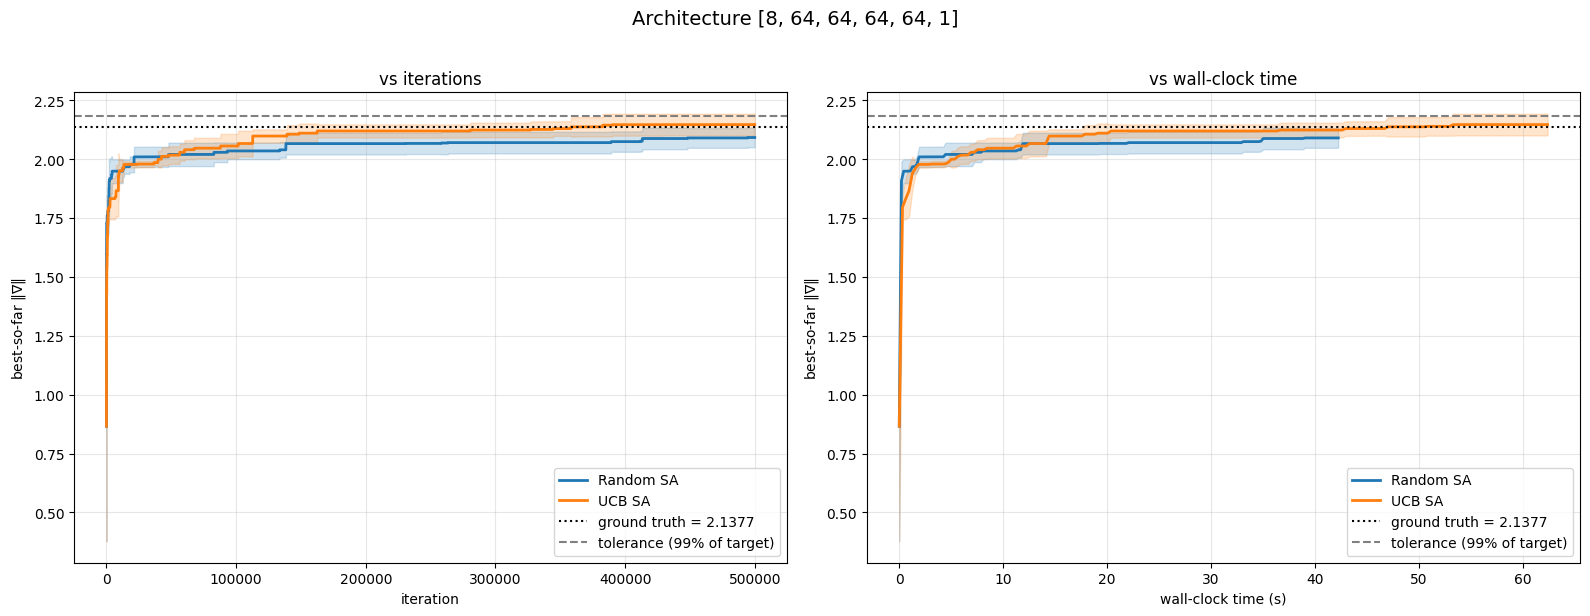

In [11]:
iters = np.arange(1, COMPARE_ITERS + 1)

for arch in ARCHITECTURES:
    r  = results[tuple(arch)]
    gt = r['gt']
    target = max(gt, max(h.max() for h in r['rand']['v_hist'] + r['ucb']['v_hist']))
    tol_y  = (1 - TOL_FRAC) * target

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Architecture {arch}', fontsize=14, y=1.02)

    # --- vs iterations ---
    ax = axes[0]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        m, s = r[key]['iter_mean'], r[key]['iter_std']
        ax.plot(iters, m, label=label, color=color, linewidth=2)
        ax.fill_between(iters, m - s, m + s, color=color, alpha=0.2)
    ax.axhline(gt,    linestyle=':',  color='black', label=f'ground truth = {gt:.4f}')
    ax.axhline(tol_y, linestyle='--', color='gray',  label=f'tolerance ({(1-TOL_FRAC)*100:.0f}% of target)')
    ax.set_xlabel('iteration')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs iterations')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # --- vs wall-clock time ---
    ax = axes[1]
    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        g, m, s = r[key]['time_grid'], r[key]['time_mean'], r[key]['time_std']
        ax.plot(g, m, label=label, color=color, linewidth=2)
        ax.fill_between(g, m - s, m + s, color=color, alpha=0.2)
    ax.axhline(gt,    linestyle=':',  color='black', label=f'ground truth = {gt:.4f}')
    ax.axhline(tol_y, linestyle='--', color='gray',  label=f'tolerance ({(1-TOL_FRAC)*100:.0f}% of target)')
    ax.set_xlabel('wall-clock time (s)')
    ax.set_ylabel(r'best-so-far $\|\nabla\|$')
    ax.set_title('vs wall-clock time')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Summary table

In [12]:
def iters_and_time_to_tol(v_hists, t_hists, tol_y):
    """For each seed: first iter (1-indexed) and time at which best-so-far >= tol_y.
    Returns (iters_array, times_array). NaN if never reached."""
    iters_out, times_out = [], []
    for v, t in zip(v_hists, t_hists):
        idx = np.argmax(v >= tol_y) if (v >= tol_y).any() else -1
        if idx == -1:
            iters_out.append(np.nan); times_out.append(np.nan)
        else:
            iters_out.append(idx + 1); times_out.append(t[idx])
    return np.array(iters_out, dtype=float), np.array(times_out, dtype=float)


def fmt_meanstd(arr, unit='', precision=4):
    finite = arr[np.isfinite(arr)]
    if len(finite) == 0:
        return f">{COMPARE_ITERS}{unit}"
    s = f"{finite.mean():.{precision}f} ± {finite.std():.{precision}f}{unit}"
    if len(finite) < len(arr):
        s += f" ({len(arr)-len(finite)}/{len(arr)} dnf)"
    return s


header = (f"{'arch':<22} {'gt':>8} {'method':>8} "
          f"{'final value':>22} {'total time':>20} "
          f"{'iters→tol':>22} {'time→tol':>22}")
print(header); print('-' * len(header))

for arch in ARCHITECTURES:
    r  = results[tuple(arch)]
    gt = r['gt']
    target = max(gt, max(h.max() for h in r['rand']['v_hist'] + r['ucb']['v_hist']))
    tol_y  = (1 - TOL_FRAC) * target

    for method, label in [('rand', 'random'), ('ucb', 'ucb')]:
        finals = np.array([h[-1] for h in r[method]['v_hist']])
        times  = np.array([t[-1] for t in r[method]['t_hist']])
        iters_tol, times_tol = iters_and_time_to_tol(
            r[method]['v_hist'], r[method]['t_hist'], tol_y)

        prefix_arch = str(arch) if method == 'rand' else ''
        prefix_gt   = f"{gt:.4f}"  if method == 'rand' else ''
        print(f"{prefix_arch:<22} {prefix_gt:>8} {label:>8} "
              f"{fmt_meanstd(finals, '', 4):>22} "
              f"{fmt_meanstd(times, ' s', 2):>20} "
              f"{fmt_meanstd(iters_tol, '', 0):>22} "
              f"{fmt_meanstd(times_tol, ' s', 3):>22}")
print()
print(f"tolerance: best-so-far >= {1-TOL_FRAC:.2%} of target (target = max(gt, best seen))")

arch                         gt   method            final value           total time              iters→tol               time→tol
----------------------------------------------------------------------------------------------------------------------------------
[2, 32, 32, 1]           1.4315   random        1.4315 ± 0.0000       31.34 ± 0.06 s                40 ± 17        0.003 ± 0.001 s
                                     ucb        1.4315 ± 0.0000       51.94 ± 0.48 s               109 ± 62        0.012 ± 0.006 s
[3, 32, 32, 32, 1]       1.9336   random        1.9343 ± 0.0014       36.99 ± 0.13 s          25527 ± 14118        1.915 ± 1.056 s
                                     ucb        1.9370 ± 0.0000       60.74 ± 1.52 s          16939 ± 12408        1.809 ± 1.325 s
[4, 32, 32, 32, 1]       2.1410   random        2.1398 ± 0.0182       37.16 ± 0.19 s                >500000              >500000 s
                                     ucb        2.1879 ± 0.0000       61.38 ± 0.70 